# Adiantando a saida

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("../Data.csv")
data = data.drop(columns=["Setpoint VD", "Setpoint VE", "tempo"])
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data = data.rename(columns={
    "VD": "Wd",
    "VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

data["theta"] = data["theta(Wd,We)"]
data["theta(Wd,We)"] = data["theta(Wd,We)"].shift(-1)


data = data.iloc[:-1]

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)", "theta"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Wd e We como linhas
    for preds in PREDICTORS:
        sns.lineplot(x=df.index, y=df[preds], ax=ax1, marker="o", label=preds,  linewidth=2)

    if PlotOut:
        ax2 = ax1.twinx()
        for target in TARGET:
            sns.lineplot(x=df.index, y=df[target], ax=ax2, marker="o", label=target, linestyle="dashed", linewidth=2)
            ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")

    # Adicionando legendas
    ax1.legend(loc="upper left")
    if PlotOut:
        ax2.legend(loc="upper right")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)

    # Salvando o gráfico
    plt.savefig(f"content/figs/{img_name}", format="svg", dpi=600)

    # Exibindo o gráfico
    plt.show()


In [3]:
data.tail()

,"x(Wd,We)","y(Wd,We)","theta(Wd,We)",Wd,We,theta
149.80,0.05,1.35,-0.81,-2.20,-2.38,-0.81
149.87,0.05,1.35,-0.80,-2.23,-2.40,-0.81
149.94,0.04,1.36,-0.80,-2.41,-2.24,-0.80
150.01,0.04,1.36,-0.80,-2.40,-2.22,-0.80
150.08,0.03,1.36,-0.80,-2.40,-2.22,-0.80


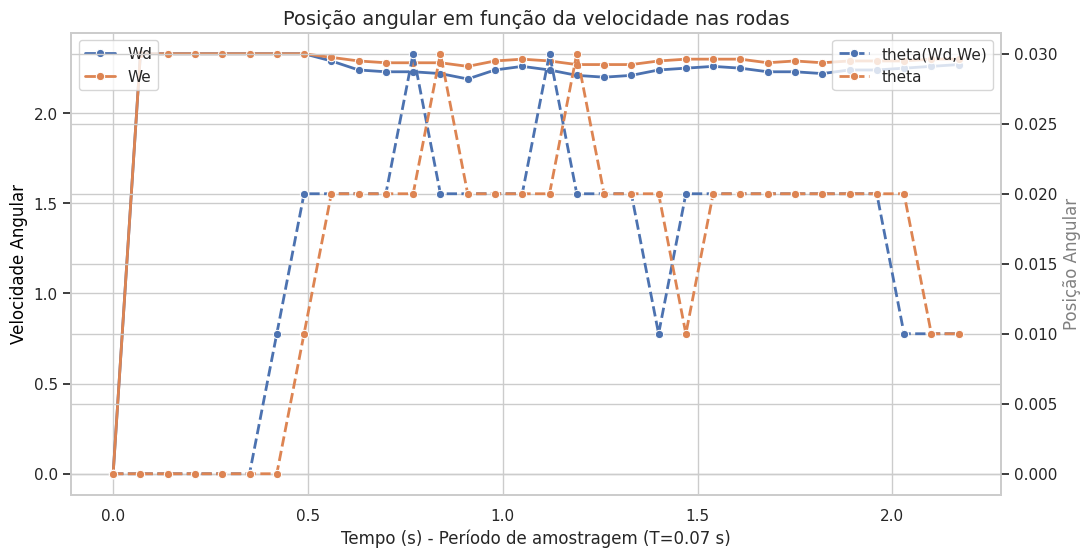

In [4]:
PlotTimeSeries(data.head(32))

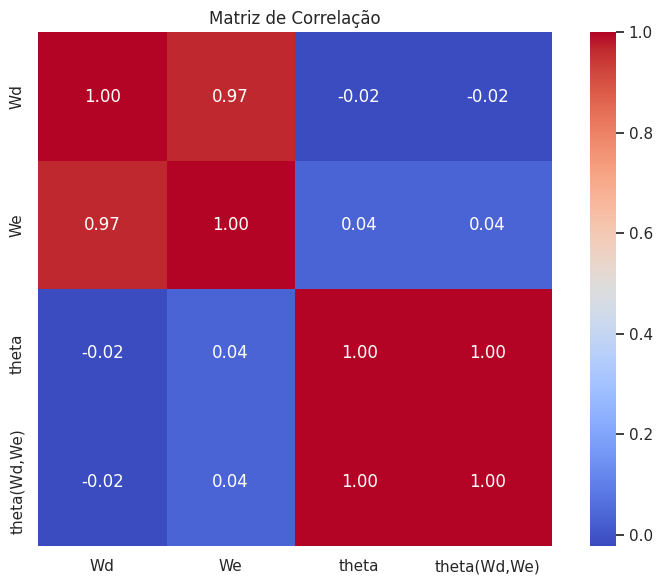

In [5]:

# Define os nomes das colunas
PREDICTORS = ["Wd", "We", "theta"]
TARGET = "theta(Wd,We)"

# Subconjunto dos dados com preditores e target
corr_data = data[PREDICTORS + [TARGET]]

# Calcula a matriz de correlação
corr_matrix = corr_data.corr()

# Exibe a matriz de correlação com seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

In [6]:
from pykrige.ok3d import OrdinaryKriging3D
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 


VARIOGRAMS = ["gaussian", "spherical", "hole-effect" ,"power", "linear"]

class Kriging3D:
    
    def __init__(self, Dataset):        
        train_data, test_data = train_test_split(Dataset, test_size=0.25, shuffle=False)

        self.train_samples_x = np.array(train_data[PREDICTORS])
        self.train_samples_y = np.array(train_data[TARGET])
        
        self.test_samples_x = np.array(test_data[PREDICTORS])
        self.test_samples_y = np.array(test_data[TARGET])
        
        self.train_time = Dataset.head(np.size(self.train_samples_y)).index
        self.test_time = Dataset.tail(np.size(self.test_samples_y)).index

        self.kriging_model = None

        
    def BuildModel(self, VariogramType):
        self.kriging_model = OrdinaryKriging3D(
            self.train_samples_x[:, 0], 
            self.train_samples_x[:, 1], 
            self.train_samples_x[:, 2], 
            self.train_samples_y, 
            variogram_model=VariogramType
        )
    
    def ComputeMetrics(self):
        self.train_pred = self.kriging_model.execute('points',
                                             self.train_samples_x[:, 0],
                                             self.train_samples_x[:, 1],
                                             self.train_samples_x[:, 2])[0]
        
        self.test_pred = self.kriging_model.execute('points',
                                             self.test_samples_x[:, 0],
                                             self.test_samples_x[:, 1],
                                             self.test_samples_x[:, 2])[0]
        return ({
                    'r2_training': r2_score(self.train_samples_y, self.train_pred),
                    'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
                    'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
                    'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

                    'r2_test': r2_score(self.test_samples_y, self.test_pred),
                    'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
                    'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
                    'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
            })
        
    
    def PlotOut(self, variogram):
        sns.set_theme(style="whitegrid")

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

        sns.lineplot(x=self.train_time, y=self.train_pred, ax=ax1, marker="o", label="train_pred", linewidth=2)
        sns.lineplot(x=self.train_time, y=self.train_samples_y, ax=ax1, marker="o", label="train_orig", linewidth=2)
        ax1.set_title("Dados de Treinamento", fontsize=13)
        ax1.set_xlabel("Tempo (s)", fontsize=12)
        ax1.set_ylabel("Velocidade Angular", fontsize=12)
        ax1.legend()

        sns.lineplot(x=self.test_time, y=self.test_pred, ax=ax2, marker="o", label="test_pred", linewidth=2)
        sns.lineplot(x=self.test_time, y=self.test_samples_y, ax=ax2, marker="o", label="test_orig", linewidth=2)
        ax2.set_title("Dados de Teste", fontsize=13)
        ax2.set_xlabel("Tempo (s)", fontsize=12)
        ax2.legend()

        fig.suptitle(f"Resultados do modelo Kriging: {variogram}", fontsize=15)


        plt.savefig(f"content/figs/{variogram}.svg", format="svg", dpi=600)

        plt.show()
                    
    
    def EvalModel(self, excel_path):
        self.models = {}
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            for variogram in VARIOGRAMS:
                self.BuildModel(VariogramType=variogram)
                metrics = self.ComputeMetrics()
                self.models[variogram] = self.kriging_model
                
                display(metrics)
                df = pd.DataFrame([metrics])  
                df.to_excel(writer, sheet_name=variogram, index=False)
                self.PlotOut(variogram)


{'r2_training': 0.9834841596182499,
 'mse_training': 0.002280069525276381,
 'mape_training': 21185114416351.324,
 'rmse_training': 0.0477500735630468,
 'r2_test': -460989063.48507494,
 'mse_test': 10273778.882974109,
 'mape_test': 4696.5190822060285,
 'rmse_test': 3205.273605010048}

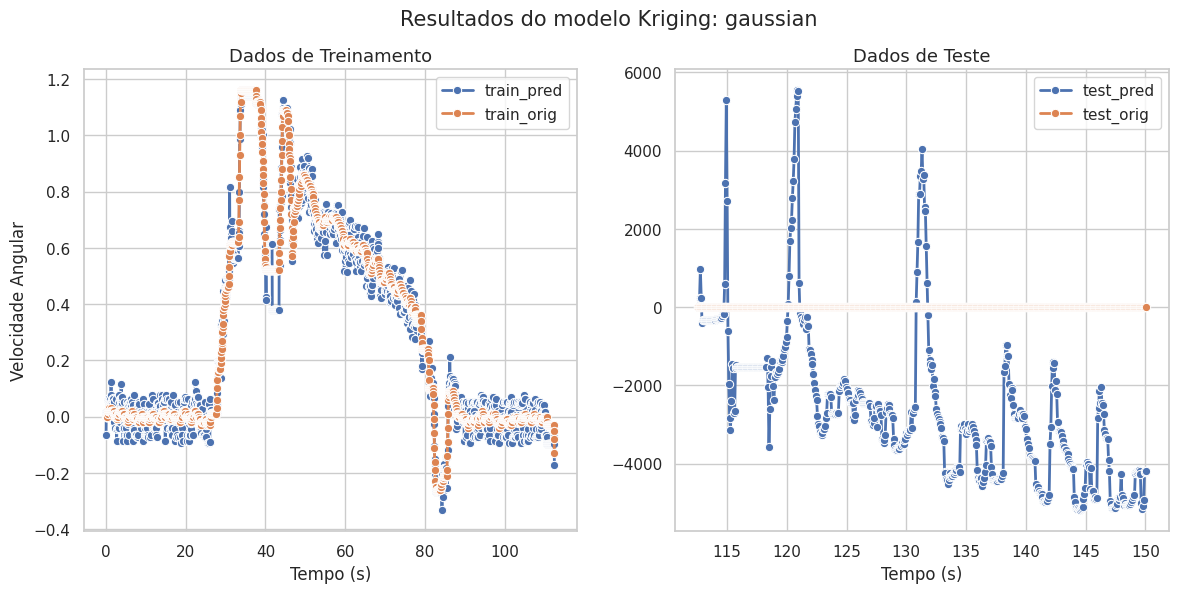

LinAlgError: Singular matrix

In [7]:
Vsg = Kriging3D(Dataset=data)        
Vsg.EvalModel("./content/KrigingMetrics.xlsx")

In [ ]:
from scipy.interpolate import UnivariateSpline
import pandas as pd
import matplotlib.pyplot as plt

def ComputeVirtualDim(Dataset):
    tempo = Dataset.index.to_numpy()

    # Tempo virtual: entre pares consecutivos
    tempo_virtual = ((tempo[:-1] + tempo[1:]) / 2).round(5)

    virtual_data = {
        "tempo_virtual": tempo_virtual
    }

    for pred in PREDICTORS:
        y = Dataset[pred].to_numpy()
        spline = UnivariateSpline(tempo, y, s=0.5)

        y_virtual = spline(tempo_virtual)
        virtual_data[pred] = y_virtual

        plt.figure(figsize=(10, 4))
        plt.plot(tempo, y, 'o', label='Reais')
        plt.plot(tempo_virtual, y_virtual, 'x', color='red', label='Virtuais (meio)')
        plt.xlabel("Tempo")
        plt.ylabel(pred)
        plt.title(f"Spline e amostras virtuais para {pred}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    y_target = Dataset[TARGET].to_numpy()
    spline_target = UnivariateSpline(tempo, y_target, s=0.5)
    target_virtual = spline_target(tempo_virtual)
    virtual_data[f'{TARGET}_spline'] = target_virtual

    plt.figure(figsize=(10, 4))
    plt.plot(tempo, y_target, 'o', label='Reais')
    plt.plot(tempo_virtual, target_virtual, 'x', color='green', label='Virtuais (meio)')
    plt.xlabel("Tempo")
    plt.ylabel(TARGET)
    plt.title(f"Spline e amostras virtuais para {TARGET}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(virtual_data)

VirtualDataset = ComputeVirtualDim(Dataset=data)


In [ ]:
VirtualDataset

In [ ]:
for variogram in VARIOGRAMS:
    model = Vsg.models[variogram]
    virtual_samples_x = np.array(VirtualDataset[PREDICTORS])

    VirtualDataset[f'{TARGET}_{variogram}'] = model.execute('points',
                                             virtual_samples_x[:, 0],
                                             virtual_samples_x[:, 1],
                                             virtual_samples_x[:, 2])[0]
        
    
VirtualDataset.to_excel("./content/VirtualData.xlsx")

In [ ]:
train_time = data.head(np.size(Vsg.train_samples_y)).index
test_time = data.head(np.size(Vsg.test_samples_y)).index

spline = UnivariateSpline(train_time, Vsg.train_samples_y, s=0.5)
test_spline = spline(test_time)

spline_metrics = {
'r2_test': r2_score(Vsg.test_samples_y, test_spline),
'mse_test': mean_squared_error(Vsg.test_samples_y, test_spline),
'mape_test': mean_absolute_percentage_error(Vsg.test_samples_y, test_spline),
'rmse_test': root_mean_squared_error(Vsg.test_samples_y, test_spline),
}

spline_metrics_df = pd.DataFrame([spline_metrics])

# Salva em nova aba no arquivo Excel
with pd.ExcelWriter("./content/KrigingMetrics.xlsx", mode="a", engine="openpyxl", if_sheet_exists="replace") as writer:
    spline_metrics_df.to_excel(writer, sheet_name="SplineMetrics", index=False)

sns.set_theme(style="whitegrid")

fig, ax2 = plt.subplots(1, 1, figsize=(14, 6), sharey=False)

sns.lineplot(x=test_time, y=test_spline, ax=ax2, marker="o", label="test_pred", linewidth=2)
sns.lineplot(x=test_time, y=Vsg.test_samples_y, ax=ax2, marker="o", label="test_orig", linewidth=2)
ax2.set_title("Dados de Teste", fontsize=13)
ax2.set_xlabel("Tempo (s)", fontsize=12)
ax2.legend()

fig.suptitle(f"Resultados do spline", fontsize=15)


plt.savefig(f"content/spline.svg", format="svg", dpi=600)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o arquivo com as amostras virtuais
virtual_df = pd.read_excel("./content/VirtualData.xlsx")

# Define o tempo
tempo_virtual = virtual_df["tempo_virtual"]

# Define as colunas de predição
model_cols = [
    "theta(Wd,We)_spline",
    "theta(Wd,We)_gaussian",
    "theta(Wd,We)_spherical",
    # "theta(Wd,We)_hole-effect",
    # "theta(Wd,We)_power",
    "theta(Wd,We)_linear"
]

# Configura o estilo
sns.set_theme(style="whitegrid")

# Cria figura e eixos
fig, ax1 = plt.subplots(figsize=(16, 6))

# Plot das predições (eixo esquerdo)
for col in model_cols:
    ax1.plot(tempo_virtual, virtual_df[col], label=col.split("_")[-1], linewidth=2)

ax1.set_xlabel("Tempo Virtual (s)", fontsize=13)
ax1.set_ylabel("theta(Wd,We)", fontsize=13)
ax1.legend(title="Modelo", loc="upper left")
ax1.grid(True)

# # Segundo eixo y (eixo direito) para Wd e We
# ax2 = ax1.twinx()
# ax2.plot(tempo_virtual, virtual_df["Wd"], color="black", linestyle="--", label="Wd", alpha=0.6)
# ax2.plot(tempo_virtual, virtual_df["We"], color="gray", linestyle="-.", label="We", alpha=0.6)
# ax2.set_ylabel("Wd / We", fontsize=13)

# Combina as legendas
lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc="upper right", fontsize=10)

# Título e layout
plt.title("Predição das amostras virtuais geradas com Kriging e spline", fontsize=16)
plt.tight_layout()
plt.savefig("content/figs/virtualPredictions.svg", format="svg", dpi=600)
plt.show()
